C:\Users\fff\AppData\Local\Temp\ipykernel_32164\1874142163.py:27: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  x1 = fsolve(f_n1, 1.0)[0]
C:\Users\fff\AppData\Local\Temp\ipykernel_32164\1874142163.py:17: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  x2 = fsolve(f_n2, 1.0)[0]
C:\Users\fff\AppData\Local\Temp\ipykernel_32164\1874142163.py:17: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  x2 = fsolve(f_n2, 1.0)[0]


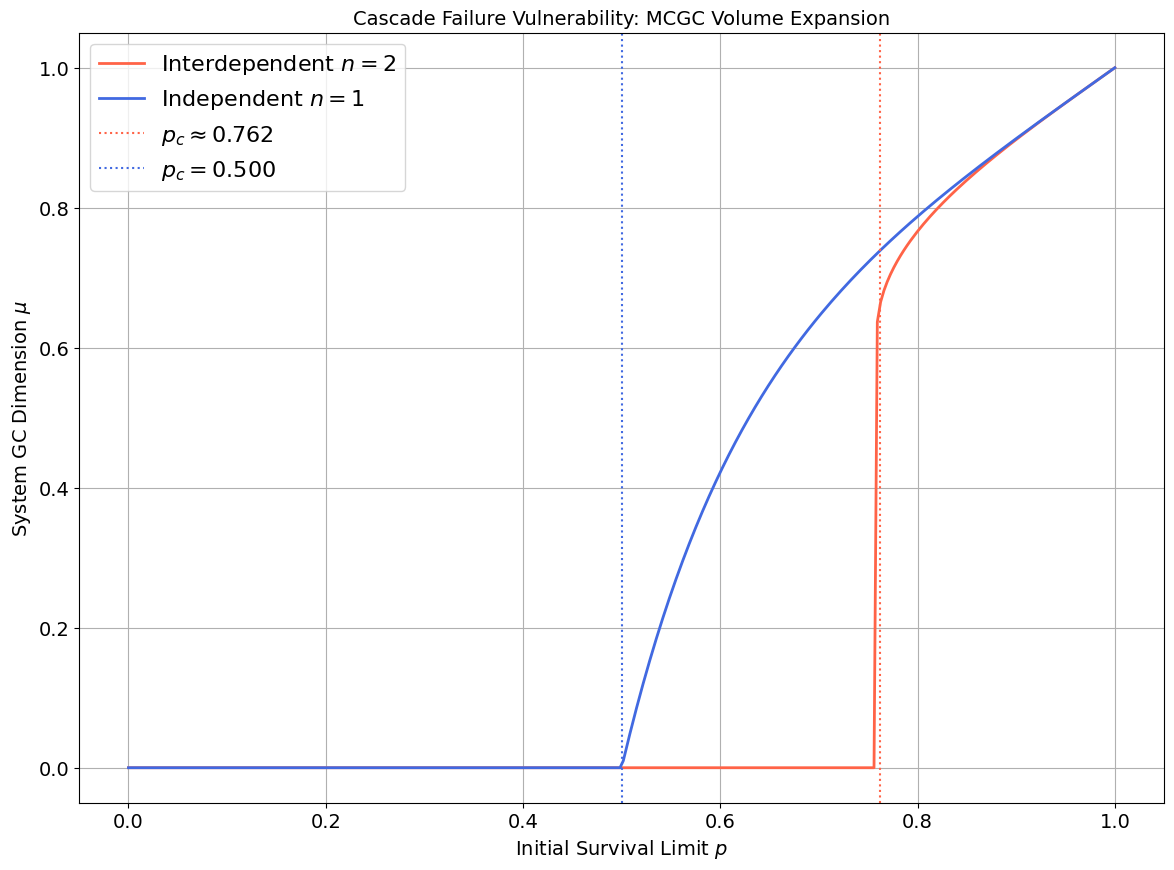

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# =========================================================
# Part (b): Multiplex 3-regular network (n=2) vs Single (n=1)
# =========================================================
def solve_Multiplex_Cascade():
    p_vals = np.linspace(0, 1, 300)
    mu_n2_vals = []
    mu_n1_vals = []
    
    for p in p_vals:
        # Solve symmetric n=2 cascade dependencies: x = p [1-(1-x)^2][1-(1-x)^3]
        f_n2 = lambda x: x - p * (1 - (1 - x)**2) * (1 - (1 - x)**3)
        # Search backward from 1.0 down towards 0 to guarantee non-trivial root intersection
        x2 = fsolve(f_n2, 1.0)[0]
        # Validate stability limit and extract size metric
        if np.isclose(f_n2(x2), 0) and x2 > 1e-4:
            mu_n2 = p * (1 - (1 - x2)**3)**2
        else:
            mu_n2 = 0.0
        mu_n2_vals.append(mu_n2)
        
        # Track standalone standard n=1 parameters: x = p [1-(1-x)^2]
        f_n1 = lambda x: x - p * (1 - (1 - x)**2)
        x1 = fsolve(f_n1, 1.0)[0]
        if np.isclose(f_n1(x1), 0) and x1 > 1e-4:
            mu_n1 = p * (1 - (1 - x1)**3)
        else:
            mu_n1 = 0.0
        mu_n1_vals.append(mu_n1)
        
    plt.figure(figsize=(14, 10))
    plt.plot(p_vals, mu_n2_vals, label='Interdependent $n=2$', color='tomato', lw=2)
    plt.plot(p_vals, mu_n1_vals, label='Independent $n=1$', color='royalblue', lw=2)
    
    # Indicate cascade failure boundary estimates
    p_c_n2 = 0.762
    p_c_n1 = 0.500
    plt.axvline(p_c_n2, color='tomato', linestyle=':', label=f'$p_c \\approx {p_c_n2:.3f}$')
    plt.axvline(p_c_n1, color='royalblue', linestyle=':', label=f'$p_c = {p_c_n1:.3f}$')
    
    plt.title('Cascade Failure Vulnerability: MCGC Volume Expansion', fontsize=14)
    plt.xlabel('Initial Survival Limit $p$', fontsize=14)
    plt.xticks(fontsize=14)
    plt.ylabel('System GC Dimension $\\mu$', fontsize=14)
    plt.yticks(fontsize=14)
    plt.legend(fontsize=16)
    plt.grid(True)
    plt.show()

solve_Multiplex_Cascade()